# **Employee Salary Prediction**

Necessary libs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
import seaborn as sns

Reading the dataframe

In [ ]:
df = pd.read_csv('/content/dataset.csv')

Checking dataframe

In [ ]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


In [ ]:
df.tail()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
737,950,"Sr Scientist, Immuno-Oncology - Oncology",$58K-$111K (Glassdoor est.),Site Name: USA - Massachusetts - Cambridge\nPo...,3.9,GSK\n3.9,"Cambridge, MA","Brentford, United Kingdom",10000+,1830,...,0,0,0,0,0,0,0,other scientist,sr,M
738,951,Senior Data Engineer,$72K-$133K (Glassdoor est.),THE CHALLENGE\nEventbrite has a world-class da...,4.4,Eventbrite\n4.4,"Nashville, TN","San Francisco, CA",1001 - 5000,2006,...,0,1,0,0,0,0,0,data engineer,sr,na
739,952,"Project Scientist - Auton Lab, Robotics Institute",$56K-$91K (Glassdoor est.),The Auton Lab at Carnegie Mellon University is...,2.6,Software Engineering Institute\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 - 1000,1984,...,0,0,0,0,0,0,0,other scientist,na,P
740,953,Data Science Manager,$95K-$160K (Glassdoor est.),Data Science ManagerResponsibilities:\n\nOvers...,3.2,"Numeric, LLC\n3.2","Allentown, PA","Chadds Ford, PA",1 - 50,-1,...,0,0,0,0,0,0,0,data scientist,na,na
741,955,Research Scientist – Security and Privacy,$61K-$126K (Glassdoor est.),Returning Candidate? Log back in to the Career...,3.6,Riverside Research Institute\n3.6,"Beavercreek, OH","Arlington, VA",501 - 1000,1967,...,0,0,0,0,0,0,0,other scientist,na,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               742 non-null    int64  
 1   Job Title           742 non-null    object 
 2   Salary Estimate     742 non-null    object 
 3   Job Description     742 non-null    object 
 4   Rating              742 non-null    float64
 5   Company Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type of ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 15  Hourly              742 non-null    int64  
 16  Employer

Droping unwanted data/columns

In [ ]:
cols_to_drop = ['index', 'Job Title', 'Salary Estimate', 'Lower Salary', 'Upper Salary', 'Industry', 'Job Description', 'Company Name', 'Location', 'Headquarters', 'Competitors', 'Sector', 'Type of ownership', 'Hourly', 'Employer provided', 'Job Location', 'company_txt', 'job_title_sim']
df = df.drop(columns=cols_to_drop)

Removing NULL values

In [ ]:
df = df.replace(-1, np.nan).replace('-1', np.nan)
df = df.dropna()

In [ ]:
df.head()

,Rating,Size,Founded,Revenue,Avg Salary(K),Age,Python,spark,aws,excel,...,scikit,tensor,hadoop,tableau,bi,flink,mongo,google_an,seniority_by_title,Degree
0,3.8,501 - 1000,1973.0,$50 to $100 million (USD),72.0,48.0,1,0,0,1,...,0,0,0,1,1,0,0,0,na,M
1,3.4,10000+,1984.0,$2 to $5 billion (USD),87.5,37.0,1,0,0,0,...,0,0,0,0,0,0,0,0,na,M
2,4.8,501 - 1000,2010.0,$100 to $500 million (USD),85.0,11.0,1,1,0,1,...,0,0,0,0,0,0,0,0,na,M
3,3.8,1001 - 5000,1965.0,$500 million to $1 billion (USD),76.5,56.0,1,0,0,0,...,0,0,0,0,0,0,0,0,na,na
4,2.9,51 - 200,1998.0,Unknown / Non-Applicable,114.5,23.0,1,0,0,1,...,0,0,0,0,0,0,0,0,na,na


Changing objects into bool values

In [ ]:
df = pd.get_dummies(df, columns=['seniority_by_title', 'Degree', 'Revenue'], drop_first=True)

Giving specific group to size

In [ ]:
size_map = {
    '1 - 50 ': 1, '51 - 200 ': 2, '201 - 500 ': 3,
    '501 - 1000 ': 4, '1001 - 5000 ': 5, '5001 - 10000 ': 6,
    '10000+ ': 7, 'Unknown': 0, '-1': 0
}
df['Size'] = df['Size'].map(size_map).fillna(0).astype(int)

In [ ]:
df.head()

,Rating,Size,Founded,Avg Salary(K),Age,Python,spark,aws,excel,sql,...,Revenue_$10 to $25 million (USD),Revenue_$10+ billion (USD),Revenue_$100 to $500 million (USD),Revenue_$2 to $5 billion (USD),Revenue_$25 to $50 million (USD),Revenue_$5 to $10 billion (USD),Revenue_$5 to $10 million (USD),Revenue_$50 to $100 million (USD),Revenue_$500 million to $1 billion (USD),Revenue_Unknown / Non-Applicable
0,3.8,4,1973.0,72.0,48.0,1,0,0,1,0,...,False,False,False,False,False,False,False,True,False,False
1,3.4,7,1984.0,87.5,37.0,1,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
2,4.8,4,2010.0,85.0,11.0,1,1,0,1,1,...,False,False,True,False,False,False,False,False,False,False
3,3.8,5,1965.0,76.5,56.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,2.9,2,1998.0,114.5,23.0,1,0,0,1,1,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690 entries, 0 to 741
Data columns (total 36 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Rating                                    690 non-null    float64
 1   Size                                      690 non-null    int64  
 2   Founded                                   690 non-null    float64
 3   Avg Salary(K)                             690 non-null    float64
 4   Age                                       690 non-null    float64
 5   Python                                    690 non-null    int64  
 6   spark                                     690 non-null    int64  
 7   aws                                       690 non-null    int64  
 8   excel                                     690 non-null    int64  
 9   sql                                       690 non-null    int64  
 10  sas                                       6

Spliting to train

In [ ]:
x = df.drop('Avg Salary(K)', axis=1)
y = df['Avg Salary(K)']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(x_test)

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Mean Absolute Error:", mae_lr)
print("R-squared Score:", r2_lr)

Mean Absolute Error: 24.00245035019562
R-squared Score: 0.4316908029307194


Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_dt = dt.predict(x_test)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Mean Absolute Error:", mae_dt)
print("R-squared Score:", r2_dt)

Mean Absolute Error: 13.305555555555555
R-squared Score: 0.5000566063127275


Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Mean Absolute Error :", mae_rf)
print("R-squared score:", r2_rf)

Mean Absolute Error : 13.5014862405107
R-squared score: 0.7143914463546676


Actual, Predicted & Residual table

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
results['Residual'] = results['Actual'] - results['Predicted']

print(results.sort_values(by='Actual'))

     Actual  Predicted   Residual
618    27.5   43.97125  -16.47125
719    37.5   50.10000  -12.60000
246    42.0   66.01500  -24.01500
666    44.5   47.76000   -3.26000
337    44.5   47.76000   -3.26000
..      ...        ...        ...
494   173.0  155.79000   17.21000
377   180.0  169.39000   10.61000
46    184.5  162.51500   21.98500
429   232.5  130.86000  101.64000
354   254.0  242.74000   11.26000

[138 rows x 3 columns]


Root Mean Squared Error

In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Linear Regression RMSE:", rmse_lr)
print("Decision Tree RMSE:", rmse_dt)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 29.72509341684177
Decision Tree RMSE: 27.87990585643372
Random Forest RMSE: 21.072520786747052


Data Summary Table

In [ ]:
summary_stats = {
    'Metric': ['Total Rows', 'Total Features', 'Avg Salary (K)', 'Min Salary (K)', 'Max Salary (K)', 'Avg Rating'],
    'Value': [
        len(df),
        x.shape[1],
        df['Avg Salary(K)'].mean(),
        df['Avg Salary(K)'].min(),
        df['Avg Salary(K)'].max(),
        df['Rating'].mean()
    ]
}
data_summary_df = pd.DataFrame(summary_stats)
print("--- Data Summary Table ---")
print(data_summary_df)

--- Data Summary Table ---
           Metric       Value
0      Total Rows  690.000000
1  Total Features   35.000000
2  Avg Salary (K)  101.055072
3  Min Salary (K)   15.500000
4  Max Salary (K)  254.000000
5      Avg Rating    3.703188


Model Comparison Table: MAE, RMSE, $R^2$

In [ ]:
model_metrics = []

model_data = [
    ("Linear Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]

for name, pred in model_data:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_metrics.append({
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R-squared': round(r2, 3)
    })

final_comparison_df = pd.DataFrame(model_metrics)
print(final_comparison_df)

               Model    MAE   RMSE  R-squared
0  Linear Regression  24.00  29.73      0.432
1      Decision Tree  13.31  27.88      0.500
2      Random Forest  13.50  21.07      0.714


Feature Importsnce Table ( RF )

In [ ]:
importances = rf.feature_importances_
feature_names = x_train.columns

feature_table = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_table = feature_table.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print("--- Top 10 Drivers of Salary ---")
print(feature_table.head(10))

--- Top 10 Drivers of Salary ---
                      Feature  Importance
0                      Rating    0.127158
1                         Age    0.100393
2                     Founded    0.099953
3                      Python    0.083495
4       seniority_by_title_sr    0.079760
5                        Size    0.048560
6                         sas    0.041494
7                       excel    0.037265
8  Revenue_$10+ billion (USD)    0.035543
9                         sql    0.033506


Comparison Graph

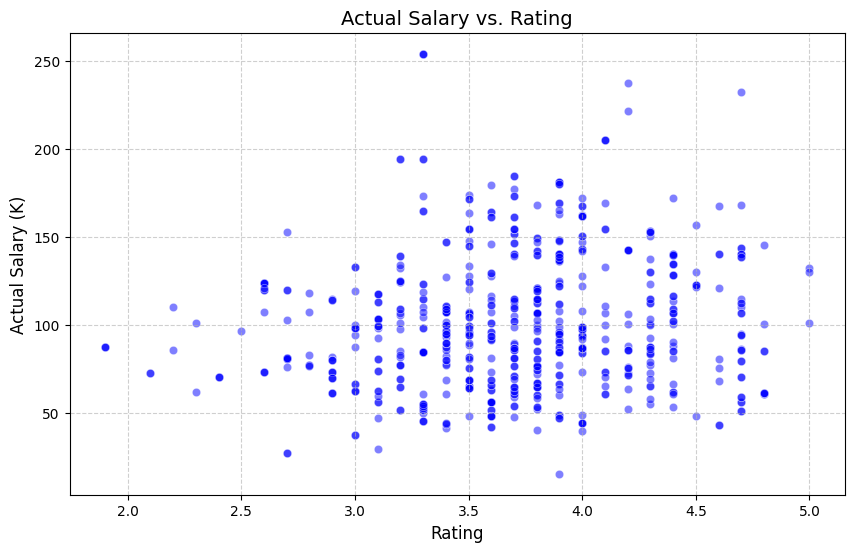

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Rating'], y=df['Avg Salary(K)'], alpha=0.5, color='blue')

plt.title('Actual Salary vs. Rating', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Actual Salary (K)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

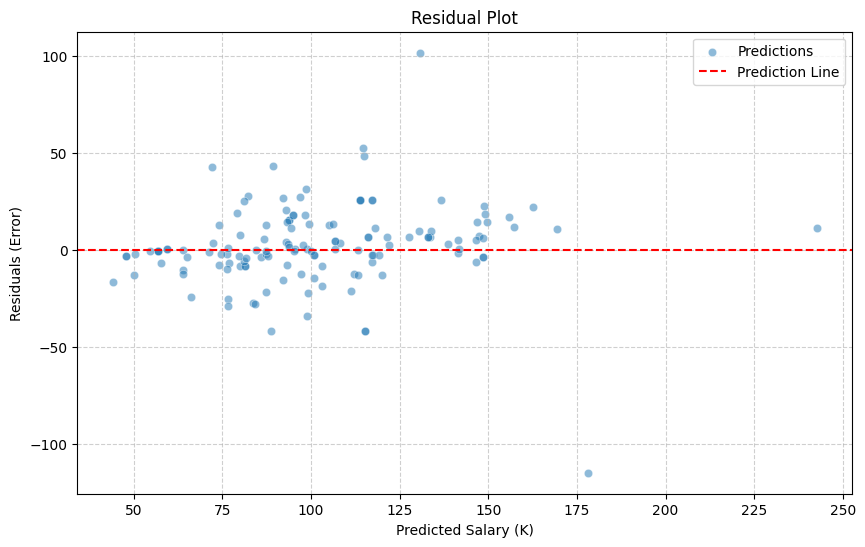

In [ ]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals, label='Predictions', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', label='Prediction Line')
plt.xlabel('Predicted Salary (K)')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

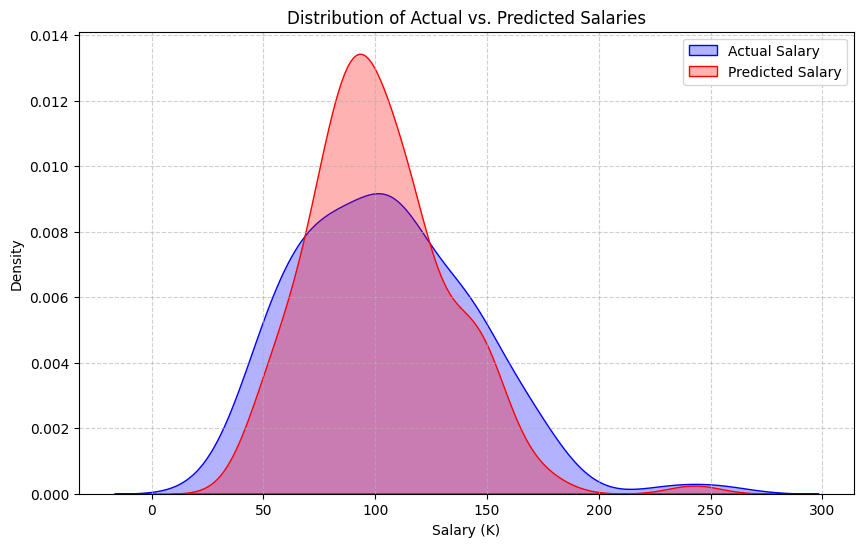

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test, label='Actual Salary', fill=True, color='blue', alpha=0.3)
sns.kdeplot(y_pred_rf, label='Predicted Salary', fill=True, color='red', alpha=0.3)
plt.title('Distribution of Actual vs. Predicted Salaries')
plt.xlabel('Salary (K)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

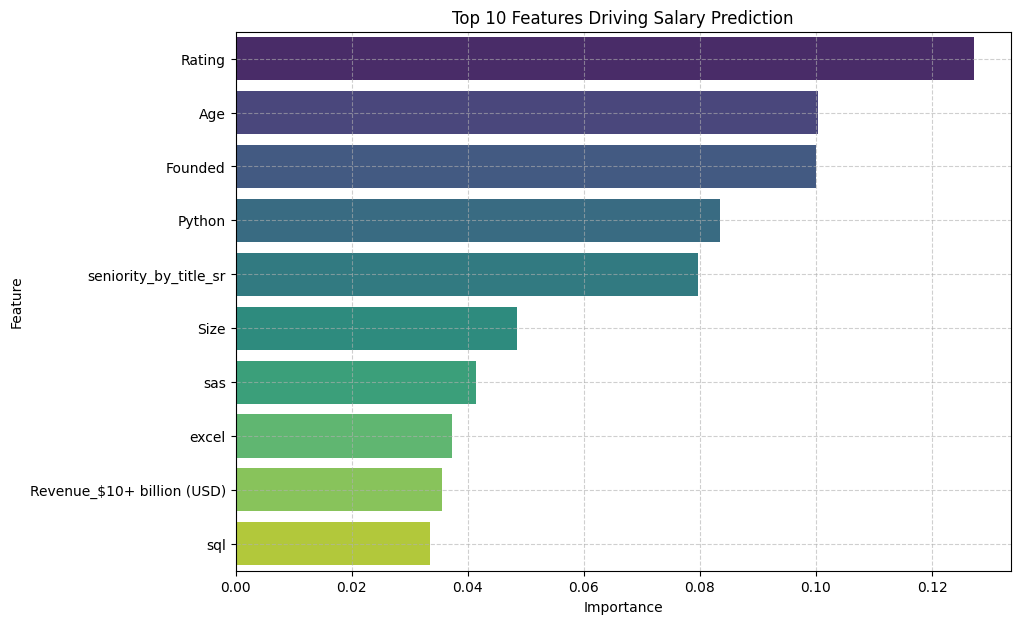

In [ ]:
importances = rf.feature_importances_
feature_names = x_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature')
plt.title('Top 10 Features Driving Salary Prediction')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The Random Forest model is the best-performing model for this dataset. It achieved an $R^2$ of 0.714, which is significantly higher than the Linear Regression (0.431) and Decision Tree (0.500) models. This means the Random Forest explains 71.4% of the variance in glassdoor salaries

Bias

In [ ]:
test_results = x_test.copy()
test_results['Abs_Error'] = abs(y_test - y_pred_rf)

bias_check = test_results.groupby('seniority_by_title_sr')['Abs_Error'].mean()

print("Average Error (MAE) by Seniority:")
print(bias_check)

Average Error (MAE) by Seniority:
seniority_by_title_sr
False    13.581179
True     13.352062
Name: Abs_Error, dtype: float64


We performed a fairness check by comparing the average prediction error (MAE) between Senior and Non-Senior job titles. The results show that the model is slightly more accurate when predicting salaries for Senior roles (13.35) compared to Non-Senior roles (13.58). Because the difference in error is very small (0.23), the model appears relatively fair and consistent across these two seniority levels.